# Финальная оценка LLM pipeline на multilabel-разметке 1000 новостей

Этот notebook заменяет старое single-label табло.

Новая постановка:
- одна новость может быть `not_relevant`;
- одна новость может иметь 1-3 релевантных фактора;
- всего в каталоге 36 бинарных factor labels;
- тональность оценивается только на релевантных парах `news_id x factor`.

Основное табло:
- `factor_micro_f1` по 36 бинарным факторным меткам;
- `factor_macro_f1_supported` только по факторам, где есть positive support;
- `per-factor F1`;
- `sample_f1_empty_correct` на уровне новости;
- `sentiment_accuracy` / `sentiment_macro_f1` только по релевантным парам.

In [1]:
from __future__ import annotations

import json
import math
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    hamming_loss,
    precision_recall_fscore_support,
)

ROOT = Path.cwd()
if not (ROOT / "manage.py").exists():
    ROOT = Path(r"C:\Users\whynot\VSCodeProjects\news-zero-shot")
sys.path.insert(0, str(ROOT))

OUTPUT_DIR = ROOT / "analysis_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

DATASET_CANDIDATES = [
    ROOT / "interfax_news_multilabel_factor_dataset_1000_wide.csv",
    OUTPUT_DIR / "interfax_news_multilabel_factor_dataset_1000_wide.csv",
    Path(r"C:\Users\whynot\Downloads\interfax_news_multilabel_factor_dataset_1000_wide.csv"),
]
DATASET_PATH = next((path for path in DATASET_CANDIDATES if path.exists()), None)
if DATASET_PATH is None:
    raise FileNotFoundError("interfax_news_multilabel_factor_dataset_1000_wide.csv not found")

PROMPT_VARIANTS = [
    "production_v1",
    "balanced_recall_v2",
    "primary_first_v2",
    "hard_negative_v2",
    "few_shot_major_v3",
]

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 160)
pd.set_option("display.max_colwidth", 180)

print(f"root={ROOT}")
print(f"dataset={DATASET_PATH}")
print(f"output_dir={OUTPUT_DIR}")

root=C:\Users\whynot\VSCodeProjects\news-zero-shot
dataset=C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\interfax_news_multilabel_factor_dataset_1000_wide.csv
output_dir=C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs


## 1. Каталог факторов и проверка кодировок

In [2]:
from analyzer.factors import FACTOR_CONFIG, FACTOR_CATALOG_VERSION

factor_keys = [item["key"] for item in FACTOR_CONFIG]
factor_names = {item["key"]: item["name"] for item in FACTOR_CONFIG}
sentiment_labels = ["negative", "neutral", "positive"]

def cyrillic_count(text: str) -> int:
    return sum(1 for char in text if 0x0400 <= ord(char) <= 0x04FF)

def repair_cp1251_utf8(text: str) -> str | None:
    try:
        return text.encode("cp1251").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        return None

def mojibake_line_count(text: str) -> int:
    count = 0
    for line in text.splitlines():
        repaired = repair_cp1251_utf8(line)
        if repaired and cyrillic_count(repaired) > cyrillic_count(line) and any(token in line for token in ("Р", "С")):
            count += 1
    return count

def file_encoding_audit(path: Path) -> dict:
    raw = path.read_bytes()
    out = {
        "path": str(path),
        "bytes": len(raw),
        "bom_utf8": raw.startswith(b"\xef\xbb\xbf"),
    }
    text = raw.decode("utf-8-sig")
    out.update(
        {
            "utf8_ok": True,
            "replacement_chars": text.count("\ufffd"),
            "cyrillic_chars": cyrillic_count(text),
            "mojibake_repairable_lines": mojibake_line_count(text),
        }
    )
    return out

encoding_audit = [
    file_encoding_audit(DATASET_PATH),
    file_encoding_audit(ROOT / "analyzer" / "factors.py"),
    file_encoding_audit(ROOT / "analyzer" / "llm_prompts.py"),
]

catalog_audit = {
    "factor_catalog_version": FACTOR_CATALOG_VERSION,
    "factor_count": len(factor_keys),
    "single_label_classes_with_not_relevant": len(factor_keys) + 1,
    "duplicate_factor_keys": sorted(pd.Series(factor_keys)[pd.Series(factor_keys).duplicated()].unique().tolist()),
    "display_order_min": min(item["display_order"] for item in FACTOR_CONFIG),
    "display_order_max": max(item["display_order"] for item in FACTOR_CONFIG),
}

display(pd.DataFrame(encoding_audit))
print(json.dumps(catalog_audit, ensure_ascii=False, indent=2))

,path,bytes,bom_utf8,utf8_ok,replacement_chars,cyrillic_chars,mojibake_repairable_lines
0,C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\interfax_news_multilabel_factor_dataset_1000_wide.csv,5903801,True,True,0,1769120,0
1,C:\Users\whynot\VSCodeProjects\news-zero-shot\analyzer\factors.py,23403,False,True,0,6963,0
2,C:\Users\whynot\VSCodeProjects\news-zero-shot\analyzer\llm_prompts.py,6821,False,True,0,2088,0


{
  "factor_catalog_version": "social-risk-factors-v2",
  "factor_count": 36,
  "single_label_classes_with_not_relevant": 37,
  "duplicate_factor_keys": [],
  "display_order_min": 1,
  "display_order_max": 36
}


## 2. Загрузка wide multilabel-разметки

In [3]:
df = pd.read_csv(DATASET_PATH, encoding="utf-8-sig")

row_id_col = "Номер строки в датасете 1000"
title_col = "Заголовок новости"
description_col = "Описание новости"
url_col = "Ссылка на новость"
relevant_count_col = "Количество релевантных факторов"

if row_id_col not in df.columns:
    row_id_col = df.columns[0]

df["dataset_row_id"] = pd.to_numeric(df[row_id_col], errors="raise").astype(int)
ids_full = df["dataset_row_id"].to_numpy()

missing_factor_columns = [f"factor__{key}" for key in factor_keys if f"factor__{key}" not in df.columns]
missing_sentiment_columns = [f"sentiment__{key}" for key in factor_keys if f"sentiment__{key}" not in df.columns]
missing_score_columns = [
    col
    for key in factor_keys
    for col in [f"relevance__{key}", f"pressure__{key}", f"confidence__{key}"]
    if col not in df.columns
]
if missing_factor_columns or missing_sentiment_columns or missing_score_columns:
    raise ValueError(
        {
            "missing_factor_columns": missing_factor_columns,
            "missing_sentiment_columns": missing_sentiment_columns,
            "missing_score_columns": missing_score_columns[:20],
        }
    )

y_true = np.column_stack(
    [
        pd.to_numeric(df[f"factor__{key}"], errors="coerce").fillna(0).astype(int).clip(0, 1).to_numpy()
        for key in factor_keys
    ]
)

sentiment_true = pd.DataFrame(
    {
        key: df[f"sentiment__{key}"].fillna("not_applicable").astype(str).str.strip().str.lower().to_numpy()
        for key in factor_keys
    },
    index=df["dataset_row_id"],
)

label_count = y_true.sum(axis=1)
factor_support = pd.Series(y_true.sum(axis=0), index=factor_keys).sort_values(ascending=False)
supported_factor_keys = [key for key in factor_keys if factor_support[key] > 0]
head_factor_keys = [key for key in factor_keys if factor_support[key] >= 25]
zero_support_factor_keys = [key for key in factor_keys if factor_support[key] == 0]

relevant_count_mismatch = None
if relevant_count_col in df.columns:
    declared_count = pd.to_numeric(df[relevant_count_col], errors="coerce").fillna(0).astype(int).to_numpy()
    relevant_count_mismatch = int((declared_count != label_count).sum())

dataset_stats = {
    "rows": int(len(df)),
    "columns": int(len(df.columns)),
    "factor_count": int(len(factor_keys)),
    "positive_factor_pairs": int(y_true.sum()),
    "not_relevant_news": int((label_count == 0).sum()),
    "relevant_news": int((label_count > 0).sum()),
    "multi_label_news": int((label_count > 1).sum()),
    "supported_factor_count": int((factor_support > 0).sum()),
    "zero_support_factor_count": int((factor_support == 0).sum()),
    "mean_labels_per_news": float(label_count.mean()),
    "mean_labels_per_relevant_news": float(label_count[label_count > 0].mean()),
    "relevant_count_mismatch": relevant_count_mismatch,
}

print(json.dumps(dataset_stats, ensure_ascii=False, indent=2))
display(pd.Series(label_count).value_counts().sort_index().rename("news_count").to_frame())
display(factor_support.rename("support").to_frame())

{
  "rows": 1000,
  "columns": 215,
  "factor_count": 36,
  "positive_factor_pairs": 915,
  "not_relevant_news": 275,
  "relevant_news": 725,
  "multi_label_news": 182,
  "supported_factor_count": 23,
  "zero_support_factor_count": 13,
  "mean_labels_per_news": 0.915,
  "mean_labels_per_relevant_news": 1.2620689655172415,
  "relevant_count_mismatch": 0
}


,news_count
0,275
1,543
2,174
3,8


,support
crime_count,244
industrial_production_index,206
enterprises_count,157
consumer_price_index,66
mortality_rate,44
life_expectancy,41
air_pollution,37
international_inflow,28
housing_area_per_capita,20
per_capita_income,16


## 3. EDA: распределение multilabel-разметки

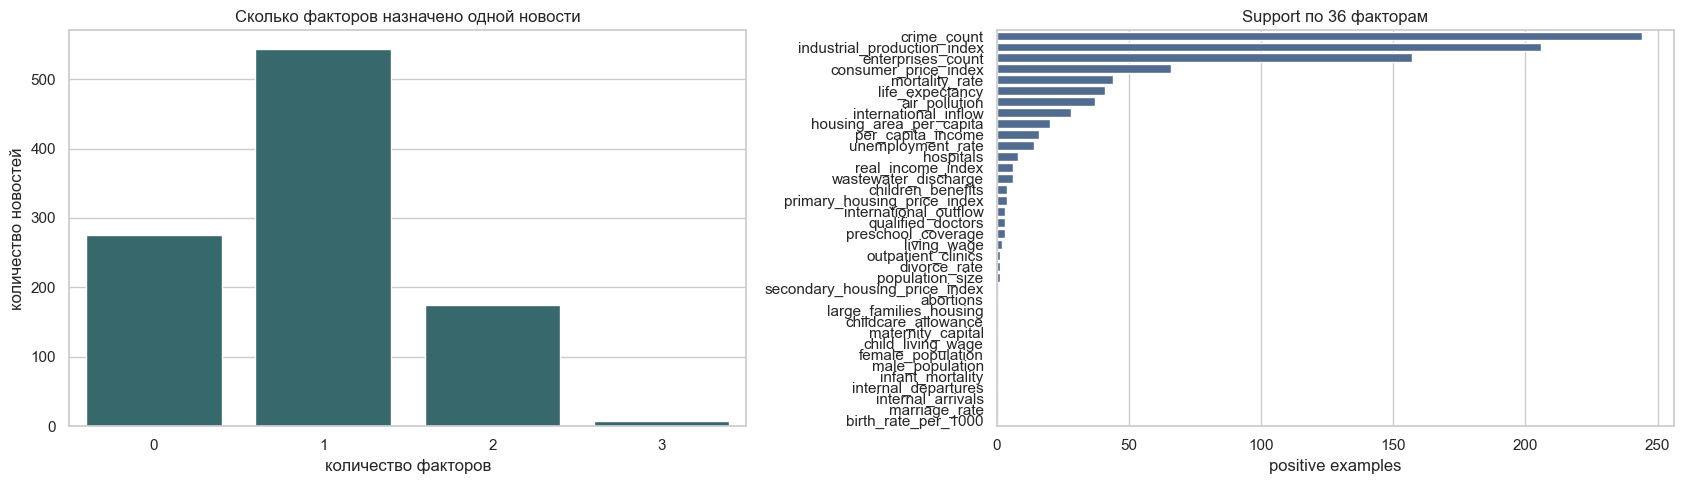

Zero-support factors:
marriage_rate, internal_arrivals, internal_departures, infant_mortality, male_population, female_population, child_living_wage, abortions, maternity_capital, childcare_allowance, large_families_housing, secondary_housing_price_index, birth_rate_per_1000


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5))

label_dist = pd.Series(label_count).value_counts().sort_index()
sns.barplot(x=label_dist.index.astype(str), y=label_dist.values, ax=axes[0], color="#2f6f73")
axes[0].set_title("Сколько факторов назначено одной новости")
axes[0].set_xlabel("количество факторов")
axes[0].set_ylabel("количество новостей")

support_plot = factor_support.reset_index()
support_plot.columns = ["factor_key", "support"]
sns.barplot(data=support_plot, y="factor_key", x="support", ax=axes[1], color="#486a9a")
axes[1].set_title("Support по 36 факторам")
axes[1].set_xlabel("positive examples")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

print("Zero-support factors:")
print(", ".join(zero_support_factor_keys))

## 4. Поиск prediction-файлов prompt experiments

In [5]:
def find_prediction_file(split: str, variant: str) -> Path | None:
    matches = sorted(
        path
        for path in OUTPUT_DIR.glob(f"prompt_search_{split}_{variant}_*.csv")
        if ".partial" not in path.name
    )
    return matches[-1] if matches else None

prediction_files = []
for split in ["search", "full"]:
    for variant in PROMPT_VARIANTS:
        path = find_prediction_file(split, variant)
        if path:
            prediction_files.append({"split": split, "variant": variant, "path": path})

prediction_index = pd.DataFrame(
    [
        {
            "split": item["split"],
            "variant": item["variant"],
            "path": str(item["path"]),
            "bytes": item["path"].stat().st_size,
        }
        for item in prediction_files
    ]
)
display(prediction_index)

,split,variant,path,bytes
0,search,production_v1,C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\prompt_search_search_production_v1_gemma4-e2b_5df03950348d_b6a2d2f27b85.csv,1648036
1,search,balanced_recall_v2,C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\prompt_search_search_balanced_recall_v2_gemma4-e2b_5df03950348d_e98b1a3c5abc.csv,1566337
2,search,primary_first_v2,C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\prompt_search_search_primary_first_v2_gemma4-e2b_5df03950348d_5f153b0981f2.csv,1559910
3,search,hard_negative_v2,C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\prompt_search_search_hard_negative_v2_gemma4-e2b_5df03950348d_1a35bcd28344.csv,1558855
4,search,few_shot_major_v3,C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\prompt_search_search_few_shot_major_v3_gemma4-e2b_5df03950348d_0c3d39008fbb.csv,1575959
5,full,production_v1,C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\prompt_search_full_production_v1_gemma4-e2b_5df03950348d_b6a2d2f27b85.csv,5489230
6,full,balanced_recall_v2,C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\prompt_search_full_balanced_recall_v2_gemma4-e2b_5df03950348d_e98b1a3c5abc.csv,5233009


## 5. Метрики для multilabel-классификации и тональности

In [6]:
def normalize_bool_series(series: pd.Series) -> pd.Series:
    if series.dtype == object:
        return series.astype(str).str.lower().isin(["true", "1", "yes", "y"])
    return series.astype(bool)

def normalize_sentiment_label(value) -> str:
    label = str(value or "neutral").strip().lower()
    if label in sentiment_labels:
        return label
    return "neutral"

def per_sample_f1_empty_correct(y: np.ndarray, p: np.ndarray) -> float:
    intersection = (y & p).sum(axis=1)
    y_count = y.sum(axis=1)
    p_count = p.sum(axis=1)
    denom = y_count + p_count
    return float(np.where(denom == 0, 1.0, 2 * intersection / np.maximum(denom, 1)).mean())

def per_sample_jaccard_empty_correct(y: np.ndarray, p: np.ndarray) -> float:
    intersection = (y & p).sum(axis=1)
    union = (y | p).sum(axis=1)
    return float(np.where(union == 0, 1.0, intersection / np.maximum(union, 1)).mean())

def load_prediction_long(path: Path) -> pd.DataFrame:
    pred = pd.read_csv(path, encoding="utf-8-sig")
    pred["is_relevant_bool"] = normalize_bool_series(pred["is_relevant"])
    pred["relevance"] = pd.to_numeric(pred["relevance"], errors="coerce").fillna(0.0)
    pred["sentiment_label_norm"] = pred["sentiment_label"].map(normalize_sentiment_label)
    return pred

def matrices_for_prediction(pred: pd.DataFrame, ids: np.ndarray, mode: str, threshold: float | None = None) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    scores = (
        pred.pivot(index="dataset_row_id", columns="factor_key", values="relevance")
        .reindex(index=ids, columns=factor_keys)
        .fillna(0.0)
        .to_numpy(float)
    )
    if mode == "default":
        labels = (
            pred.pivot(index="dataset_row_id", columns="factor_key", values="is_relevant_bool")
            .reindex(index=ids, columns=factor_keys)
            .fillna(False)
            .astype(bool)
            .to_numpy(int)
        )
    elif mode == "threshold":
        if threshold is None:
            raise ValueError("threshold is required")
        labels = (scores >= threshold).astype(int)
    else:
        raise ValueError(mode)

    sentiment_matrix = (
        pred.pivot(index="dataset_row_id", columns="factor_key", values="sentiment_label_norm")
        .reindex(index=ids, columns=factor_keys)
        .fillna("neutral")
        .astype(str)
        .to_numpy()
    )
    return scores, labels, sentiment_matrix

def subset_truth(ids: np.ndarray) -> tuple[np.ndarray, pd.DataFrame]:
    positions = pd.Series(np.arange(len(df)), index=df["dataset_row_id"]).reindex(ids).to_numpy()
    if pd.isna(positions).any():
        missing = ids[pd.isna(positions)]
        raise ValueError(f"Unknown dataset ids: {missing[:10]}")
    positions = positions.astype(int)
    return y_true[positions], sentiment_true.reindex(ids)

def evaluate_multilabel(
    y: np.ndarray,
    p: np.ndarray,
    true_sentiment: pd.DataFrame,
    pred_sentiment_matrix: np.ndarray,
    name: str,
    variant: str,
    split: str,
    mode: str,
    threshold: float | None,
) -> dict:
    p = p.astype(int)
    supported_idx = [factor_keys.index(key) for key in factor_keys if y[:, factor_keys.index(key)].sum() > 0]
    head_idx = [factor_keys.index(key) for key in factor_keys if y[:, factor_keys.index(key)].sum() >= 25]

    y_any = (y.sum(axis=1) > 0).astype(int)
    p_any = (p.sum(axis=1) > 0).astype(int)
    any_precision, any_recall, any_f1, _ = precision_recall_fscore_support(
        y_any,
        p_any,
        average="binary",
        zero_division=0,
    )
    micro_precision, micro_recall, micro_f1, _ = precision_recall_fscore_support(
        y,
        p,
        average="micro",
        zero_division=0,
    )
    empty_specificity = ((y_any == 0) & (p_any == 0)).sum() / max(1, (y_any == 0).sum())

    true_sentiments_all = []
    pred_sentiments_all = []
    true_sentiments_cond = []
    pred_sentiments_cond = []
    predicted_true_pair_count = 0
    for row_idx in range(y.shape[0]):
        for factor_idx, factor_key in enumerate(factor_keys):
            if y[row_idx, factor_idx] != 1:
                continue
            true_label = normalize_sentiment_label(true_sentiment.iloc[row_idx][factor_key])
            pred_label = normalize_sentiment_label(pred_sentiment_matrix[row_idx, factor_idx])
            true_sentiments_all.append(true_label)
            if p[row_idx, factor_idx] == 1:
                pred_sentiments_all.append(pred_label)
                true_sentiments_cond.append(true_label)
                pred_sentiments_cond.append(pred_label)
                predicted_true_pair_count += 1
            else:
                pred_sentiments_all.append("__missed_factor__")

    sentiment_all_accuracy = accuracy_score(true_sentiments_all, pred_sentiments_all) if true_sentiments_all else 0.0
    sentiment_all_macro_f1 = (
        f1_score(true_sentiments_all, pred_sentiments_all, labels=sentiment_labels, average="macro", zero_division=0)
        if true_sentiments_all
        else 0.0
    )
    sentiment_cond_accuracy = (
        accuracy_score(true_sentiments_cond, pred_sentiments_cond) if true_sentiments_cond else 0.0
    )
    sentiment_cond_macro_f1 = (
        f1_score(true_sentiments_cond, pred_sentiments_cond, labels=sentiment_labels, average="macro", zero_division=0)
        if true_sentiments_cond
        else 0.0
    )

    return {
        "name": name,
        "variant": variant,
        "split": split,
        "mode": mode,
        "threshold": threshold,
        "n_news": int(y.shape[0]),
        "true_positive_pairs": int(y.sum()),
        "pred_positive_pairs": int(p.sum()),
        "pred_relevant_news": int(p_any.sum()),
        "mean_true_labels_per_news": float(y.sum(axis=1).mean()),
        "mean_pred_labels_per_news": float(p.sum(axis=1).mean()),
        "factor_micro_f1": float(micro_f1),
        "factor_micro_precision": float(micro_precision),
        "factor_micro_recall": float(micro_recall),
        "factor_macro_f1_supported": float(
            f1_score(y[:, supported_idx], p[:, supported_idx], average="macro", zero_division=0)
            if supported_idx
            else 0.0
        ),
        "factor_macro_f1_all36": float(f1_score(y, p, average="macro", zero_division=0)),
        "factor_macro_f1_head_ge25": float(
            f1_score(y[:, head_idx], p[:, head_idx], average="macro", zero_division=0)
            if head_idx
            else 0.0
        ),
        "factor_weighted_f1": float(f1_score(y, p, average="weighted", zero_division=0)),
        "sample_f1_empty_correct": per_sample_f1_empty_correct(y, p),
        "sample_jaccard_empty_correct": per_sample_jaccard_empty_correct(y, p),
        "exact_match": float((y == p).all(axis=1).mean()),
        "hamming_loss": float(hamming_loss(y, p)),
        "any_relevant_f1": float(any_f1),
        "any_relevant_precision": float(any_precision),
        "any_relevant_recall": float(any_recall),
        "empty_specificity": float(empty_specificity),
        "sentiment_accuracy_all_true_pairs_missed_wrong": float(sentiment_all_accuracy),
        "sentiment_macro_f1_all_true_pairs_missed_wrong": float(sentiment_all_macro_f1),
        "sentiment_accuracy_on_predicted_true_pairs": float(sentiment_cond_accuracy),
        "sentiment_macro_f1_on_predicted_true_pairs": float(sentiment_cond_macro_f1),
        "sentiment_true_pair_coverage": float(predicted_true_pair_count / max(1, len(true_sentiments_all))),
        "sentiment_eval_true_pairs": int(len(true_sentiments_all)),
        "sentiment_eval_predicted_true_pairs": int(predicted_true_pair_count),
    }

metric_cols = [
    "name",
    "split",
    "n_news",
    "factor_micro_f1",
    "factor_micro_precision",
    "factor_micro_recall",
    "factor_macro_f1_supported",
    "sample_f1_empty_correct",
    "any_relevant_f1",
    "exact_match",
    "sentiment_accuracy_on_predicted_true_pairs",
    "sentiment_accuracy_all_true_pairs_missed_wrong",
    "sentiment_true_pair_coverage",
    "mean_pred_labels_per_news",
]

## 6. Prompt experiments на search sample

,name,split,n_news,factor_micro_f1,factor_micro_precision,factor_micro_recall,factor_macro_f1_supported,sample_f1_empty_correct,any_relevant_f1,exact_match,sentiment_accuracy_on_predicted_true_pairs,sentiment_accuracy_all_true_pairs_missed_wrong,sentiment_true_pair_coverage,mean_pred_labels_per_news
3,balanced_recall_v2__threshold_0.30,search,300,0.4862,0.5593,0.4300,0.2469,0.5119,0.8455,0.3800,0.6818,0.2932,0.4300,0.7867
2,balanced_recall_v2__default,search,300,0.4648,0.6728,0.3550,0.2443,0.5119,0.7453,0.4000,0.8073,0.2866,0.3550,0.5400
9,few_shot_major_v3__threshold_0.30,search,300,0.4514,0.4833,0.4235,0.2480,0.4283,0.8502,0.3167,0.5538,0.2345,0.4235,0.8967
5,primary_first_v2__threshold_0.30,search,300,0.4209,0.4913,0.3681,0.2495,0.4413,0.8241,0.3400,0.6460,0.2378,0.3681,0.7667
4,primary_first_v2__default,search,300,0.3657,0.5956,0.2638,0.2299,0.4317,0.6704,0.3500,0.8889,0.2345,0.2638,0.4533
8,few_shot_major_v3__default,search,300,0.3529,0.5778,0.2541,0.2207,0.4028,0.6482,0.3200,0.8974,0.2280,0.2541,0.4500
7,hard_negative_v2__threshold_0.30,search,300,0.2820,0.7105,0.1759,0.2016,0.3872,0.4749,0.3333,0.6111,0.1075,0.1759,0.2533
1,production_v1__threshold_0.30,search,300,0.2778,0.4037,0.2117,0.1801,0.3547,0.7037,0.2767,0.6462,0.1368,0.2117,0.5367
0,production_v1__default,search,300,0.2315,0.4747,0.1531,0.1677,0.3422,0.5511,0.2833,0.8723,0.1336,0.1531,0.3300
6,hard_negative_v2__default,search,300,0.1915,0.7083,0.1107,0.1707,0.3328,0.3247,0.2967,0.9412,0.1042,0.1107,0.1600


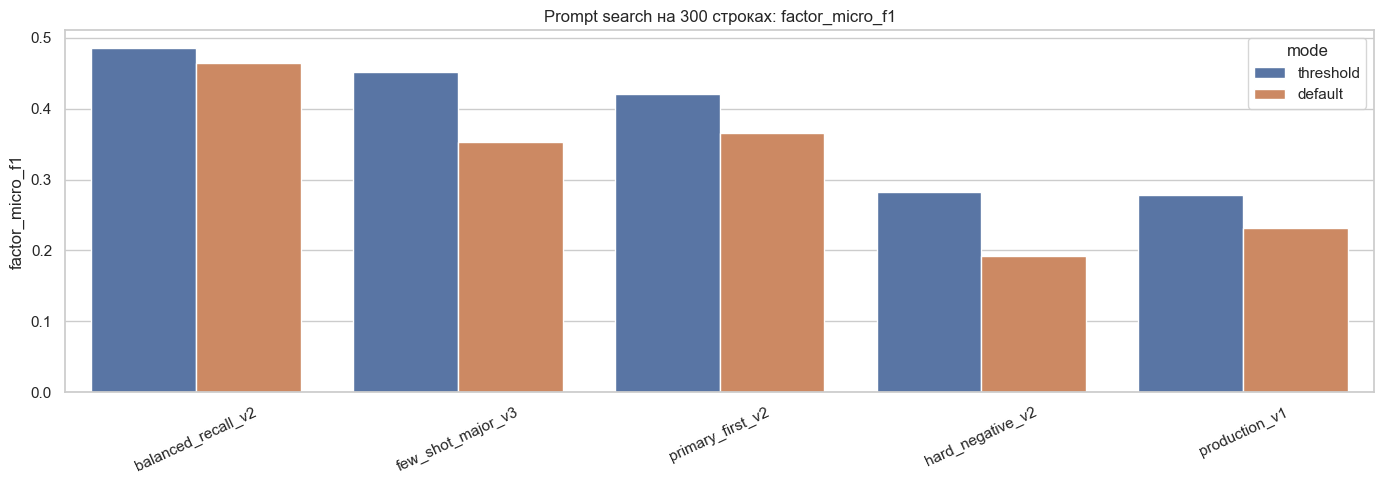

In [7]:
search_rows = []
prediction_cache = {}

for item in prediction_files:
    pred = load_prediction_long(item["path"])
    ids = np.array(sorted(pred["dataset_row_id"].unique()), dtype=int)
    y_sub, sentiment_sub = subset_truth(ids)
    scores, default_labels, sent_matrix = matrices_for_prediction(pred, ids, mode="default")
    prediction_cache[(item["split"], item["variant"])] = {
        "path": item["path"],
        "ids": ids,
        "pred": pred,
        "scores": scores,
        "default_labels": default_labels,
        "sentiment_matrix": sent_matrix,
        "y": y_sub,
        "sentiment_true": sentiment_sub,
    }
    if item["split"] == "search":
        search_rows.append(
            evaluate_multilabel(
                y_sub,
                default_labels,
                sentiment_sub,
                sent_matrix,
                name=f"{item['variant']}__default",
                variant=item["variant"],
                split="search",
                mode="default",
                threshold=None,
            )
        )
        threshold_labels = (scores >= 0.30).astype(int)
        search_rows.append(
            evaluate_multilabel(
                y_sub,
                threshold_labels,
                sentiment_sub,
                sent_matrix,
                name=f"{item['variant']}__threshold_0.30",
                variant=item["variant"],
                split="search",
                mode="threshold",
                threshold=0.30,
            )
        )

search_metrics = pd.DataFrame(search_rows).sort_values(
    ["factor_micro_f1", "sample_f1_empty_correct"],
    ascending=False,
)
display(search_metrics[metric_cols].round(4))

fig, ax = plt.subplots(figsize=(14, 5))
plot_df = search_metrics.copy()
sns.barplot(data=plot_df, x="variant", y="factor_micro_f1", hue="mode", ax=ax)
ax.set_title("Prompt search на 300 строках: factor_micro_f1")
ax.set_xlabel("")
ax.set_ylabel("factor_micro_f1")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

## 7. Full evaluation: production vs лучший prompt

In [8]:
full_rows = []
for variant in ["production_v1", "balanced_recall_v2"]:
    key = ("full", variant)
    if key not in prediction_cache:
        continue
    item = prediction_cache[key]
    full_rows.append(
        evaluate_multilabel(
            item["y"],
            item["default_labels"],
            item["sentiment_true"],
            item["sentiment_matrix"],
            name=f"{variant}__default",
            variant=variant,
            split="full",
            mode="default",
            threshold=None,
        )
    )
    for threshold in [0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50, 0.60]:
        full_rows.append(
            evaluate_multilabel(
                item["y"],
                (item["scores"] >= threshold).astype(int),
                item["sentiment_true"],
                item["sentiment_matrix"],
                name=f"{variant}__threshold_{threshold:.2f}",
                variant=variant,
                split="full",
                mode="threshold",
                threshold=float(threshold),
            )
        )

full_metrics = pd.DataFrame(full_rows).sort_values(
    ["factor_micro_f1", "sample_f1_empty_correct"],
    ascending=False,
)
display(full_metrics[metric_cols].round(4))

best_full = full_metrics.iloc[0].copy()
best_variant = best_full["variant"]
best_mode = best_full["mode"]
best_threshold = best_full["threshold"]
print(f"best_full={best_full['name']}")

,name,split,n_news,factor_micro_f1,factor_micro_precision,factor_micro_recall,factor_macro_f1_supported,sample_f1_empty_correct,any_relevant_f1,exact_match,sentiment_accuracy_on_predicted_true_pairs,sentiment_accuracy_all_true_pairs_missed_wrong,sentiment_true_pair_coverage,mean_pred_labels_per_news
10,balanced_recall_v2__threshold_0.15,full,1000,0.4888,0.5300,0.4536,0.2605,0.4879,0.8089,0.404,0.5687,0.2579,0.4536,0.783
11,balanced_recall_v2__threshold_0.20,full,1000,0.4888,0.5300,0.4536,0.2605,0.4879,0.8089,0.404,0.5687,0.2579,0.4536,0.783
12,balanced_recall_v2__threshold_0.25,full,1000,0.4888,0.5300,0.4536,0.2605,0.4879,0.8089,0.404,0.5687,0.2579,0.4536,0.783
13,balanced_recall_v2__threshold_0.30,full,1000,0.4888,0.5300,0.4536,0.2605,0.4879,0.8089,0.404,0.5687,0.2579,0.4536,0.783
9,balanced_recall_v2__default,full,1000,0.4327,0.6091,0.3355,0.2592,0.4784,0.6954,0.406,0.7459,0.2503,0.3355,0.504
14,balanced_recall_v2__threshold_0.35,full,1000,0.4299,0.6934,0.3115,0.2532,0.4920,0.6507,0.431,0.7404,0.2306,0.3115,0.411
15,balanced_recall_v2__threshold_0.40,full,1000,0.4299,0.6934,0.3115,0.2532,0.4920,0.6507,0.431,0.7404,0.2306,0.3115,0.411
16,balanced_recall_v2__threshold_0.50,full,1000,0.4299,0.6934,0.3115,0.2532,0.4920,0.6507,0.431,0.7404,0.2306,0.3115,0.411
17,balanced_recall_v2__threshold_0.60,full,1000,0.4299,0.6934,0.3115,0.2532,0.4920,0.6507,0.431,0.7404,0.2306,0.3115,0.411
1,production_v1__threshold_0.15,full,1000,0.2831,0.3878,0.2230,0.1598,0.3671,0.6787,0.315,0.6520,0.1454,0.2230,0.526


best_full=balanced_recall_v2__threshold_0.15


## 8. Threshold sweep для лучшего prompt

,threshold,factor_micro_f1,factor_micro_precision,factor_micro_recall,sample_f1_empty_correct,any_relevant_f1,empty_specificity,mean_pred_labels_per_news,sentiment_accuracy_on_predicted_true_pairs
0,0.05,0.4877,0.5273,0.4536,0.4859,0.8095,0.4327,0.787,0.5687
1,0.10,0.4877,0.5273,0.4536,0.4859,0.8095,0.4327,0.787,0.5687
2,0.15,0.4888,0.5300,0.4536,0.4879,0.8089,0.4400,0.783,0.5687
3,0.20,0.4888,0.5300,0.4536,0.4879,0.8089,0.4400,0.783,0.5687
4,0.25,0.4888,0.5300,0.4536,0.4879,0.8089,0.4400,0.783,0.5687
5,0.30,0.4888,0.5300,0.4536,0.4879,0.8089,0.4400,0.783,0.5687
6,0.35,0.4299,0.6934,0.3115,0.4920,0.6507,0.8764,0.411,0.7404
7,0.40,0.4299,0.6934,0.3115,0.4920,0.6507,0.8764,0.411,0.7404
8,0.45,0.4299,0.6934,0.3115,0.4920,0.6507,0.8764,0.411,0.7404
9,0.50,0.4299,0.6934,0.3115,0.4920,0.6507,0.8764,0.411,0.7404


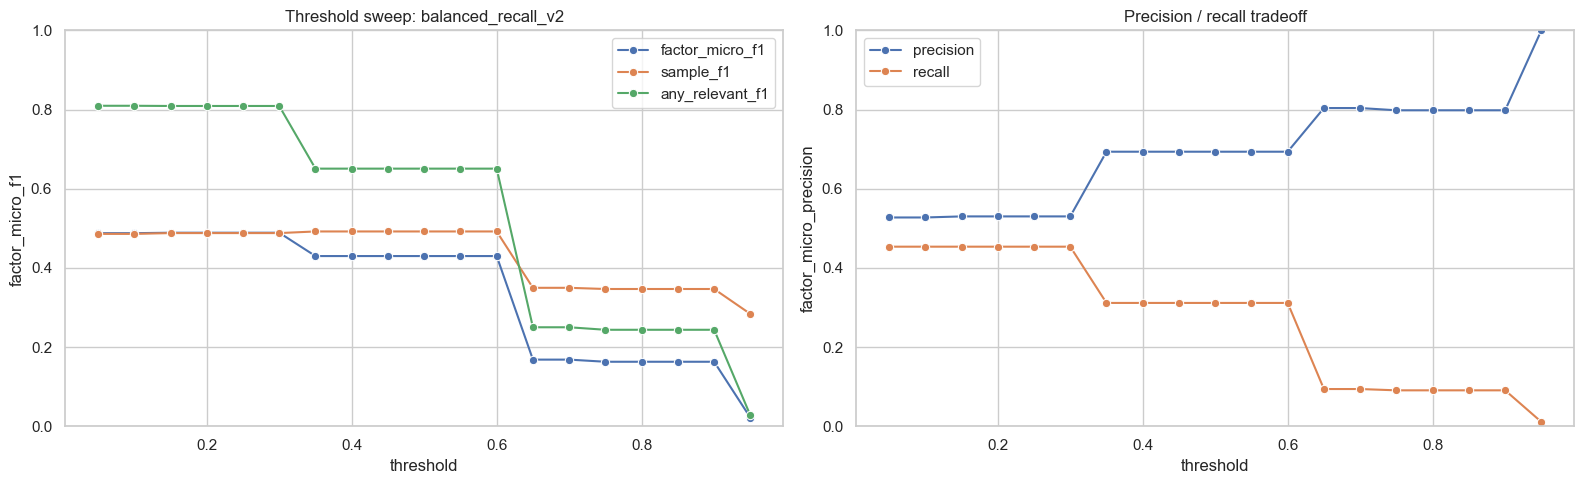

In [9]:
best_prompt_key = ("full", str(best_variant))
best_prompt_cache = prediction_cache[best_prompt_key]

sweep_rows = []
for threshold in np.round(np.arange(0.05, 0.96, 0.05), 2):
    sweep_rows.append(
        evaluate_multilabel(
            best_prompt_cache["y"],
            (best_prompt_cache["scores"] >= threshold).astype(int),
            best_prompt_cache["sentiment_true"],
            best_prompt_cache["sentiment_matrix"],
            name=f"{best_variant}__threshold_{threshold:.2f}",
            variant=str(best_variant),
            split="full",
            mode="threshold",
            threshold=float(threshold),
        )
    )

threshold_sweep = pd.DataFrame(sweep_rows)
display(
    threshold_sweep[
        [
            "threshold",
            "factor_micro_f1",
            "factor_micro_precision",
            "factor_micro_recall",
            "sample_f1_empty_correct",
            "any_relevant_f1",
            "empty_specificity",
            "mean_pred_labels_per_news",
            "sentiment_accuracy_on_predicted_true_pairs",
        ]
    ].round(4)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(data=threshold_sweep, x="threshold", y="factor_micro_f1", marker="o", ax=axes[0], label="factor_micro_f1")
sns.lineplot(data=threshold_sweep, x="threshold", y="sample_f1_empty_correct", marker="o", ax=axes[0], label="sample_f1")
sns.lineplot(data=threshold_sweep, x="threshold", y="any_relevant_f1", marker="o", ax=axes[0], label="any_relevant_f1")
axes[0].set_title(f"Threshold sweep: {best_variant}")
axes[0].set_ylim(0, 1)

sns.lineplot(data=threshold_sweep, x="threshold", y="factor_micro_precision", marker="o", ax=axes[1], label="precision")
sns.lineplot(data=threshold_sweep, x="threshold", y="factor_micro_recall", marker="o", ax=axes[1], label="recall")
axes[1].set_title("Precision / recall tradeoff")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 9. Финальное табло

,metric,production_default,balanced_default,final_best
0,factor_micro_f1,0.2431,0.4327,0.4888
1,sample_f1,0.3678,0.4784,0.4879
2,any_relevant_f1,0.5286,0.6954,0.8089
3,supported_macro_f1,0.1497,0.2592,0.2605
4,sentiment_acc_cond,0.8733,0.7459,0.5687
5,exact_match,0.3270,0.4060,0.4040


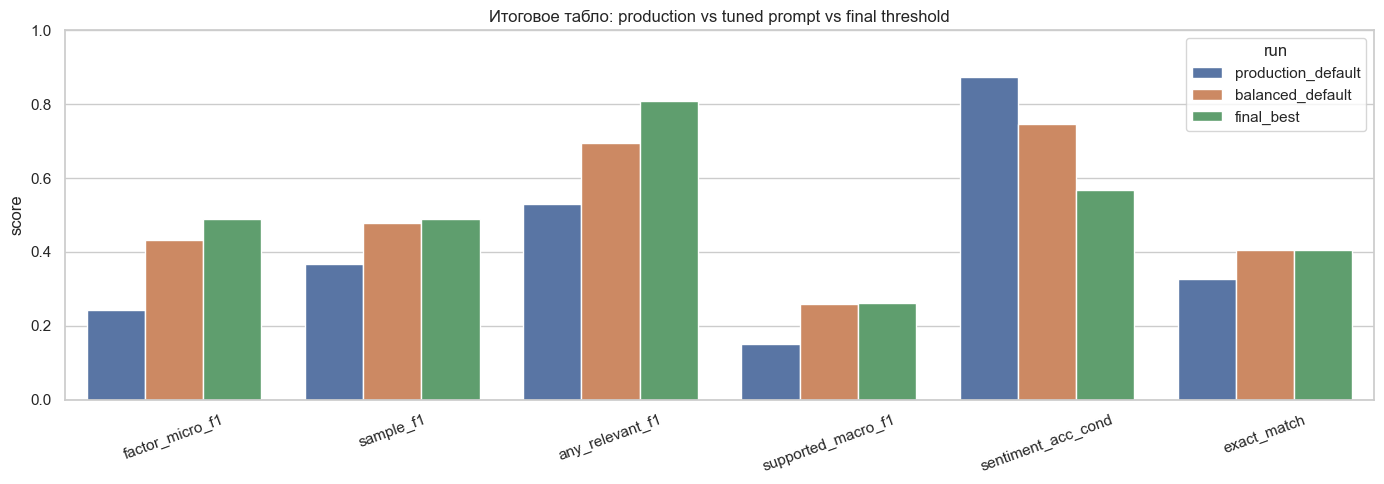

In [10]:
final_row = full_metrics.iloc[0].to_dict()
production_default = full_metrics[full_metrics["name"] == "production_v1__default"].iloc[0].to_dict()
balanced_default = full_metrics[full_metrics["name"] == "balanced_recall_v2__default"].iloc[0].to_dict()

dashboard = pd.DataFrame(
    [
        {"metric": "factor_micro_f1", "production_default": production_default["factor_micro_f1"], "balanced_default": balanced_default["factor_micro_f1"], "final_best": final_row["factor_micro_f1"]},
        {"metric": "sample_f1", "production_default": production_default["sample_f1_empty_correct"], "balanced_default": balanced_default["sample_f1_empty_correct"], "final_best": final_row["sample_f1_empty_correct"]},
        {"metric": "any_relevant_f1", "production_default": production_default["any_relevant_f1"], "balanced_default": balanced_default["any_relevant_f1"], "final_best": final_row["any_relevant_f1"]},
        {"metric": "supported_macro_f1", "production_default": production_default["factor_macro_f1_supported"], "balanced_default": balanced_default["factor_macro_f1_supported"], "final_best": final_row["factor_macro_f1_supported"]},
        {"metric": "sentiment_acc_cond", "production_default": production_default["sentiment_accuracy_on_predicted_true_pairs"], "balanced_default": balanced_default["sentiment_accuracy_on_predicted_true_pairs"], "final_best": final_row["sentiment_accuracy_on_predicted_true_pairs"]},
        {"metric": "exact_match", "production_default": production_default["exact_match"], "balanced_default": balanced_default["exact_match"], "final_best": final_row["exact_match"]},
    ]
)
display(dashboard.round(4))

plot_dash = dashboard.melt(id_vars=["metric"], var_name="run", value_name="score")
fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(data=plot_dash, x="metric", y="score", hue="run", ax=ax)
ax.set_title("Итоговое табло: production vs tuned prompt vs final threshold")
ax.set_xlabel("")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## 10. Per-factor F1 для финальной конфигурации

,factor_key,factor_name,support,predicted_positive,precision,recall,f1
31,crime_count,Количество преступлений,244,125,0.7840,0.4016,0.5312
29,industrial_production_index,Индексы промышленного производства,206,248,0.5806,0.6990,0.6344
30,enterprises_count,Число предприятий и организаций,157,99,0.7576,0.4777,0.5859
26,consumer_price_index,Индексы потребительских цен,66,102,0.5000,0.7727,0.6071
34,mortality_rate,Коэффициент смертности на 1000 человек,44,5,0.0000,0.0000,0.0000
8,life_expectancy,Ожидаемая продолжительность жизни,41,1,1.0000,0.0244,0.0476
32,air_pollution,Выбросы загрязняющих веществ в атмосферный воздух,37,30,0.4000,0.3243,0.3582
3,international_inflow,Число прибывших в страну,28,121,0.1901,0.8214,0.3087
25,housing_area_per_capita,Общая площадь жилья на одного жителя,20,1,0.0000,0.0000,0.0000
11,per_capita_income,Среднедушевые денежные доходы населения,16,1,1.0000,0.0625,0.1176


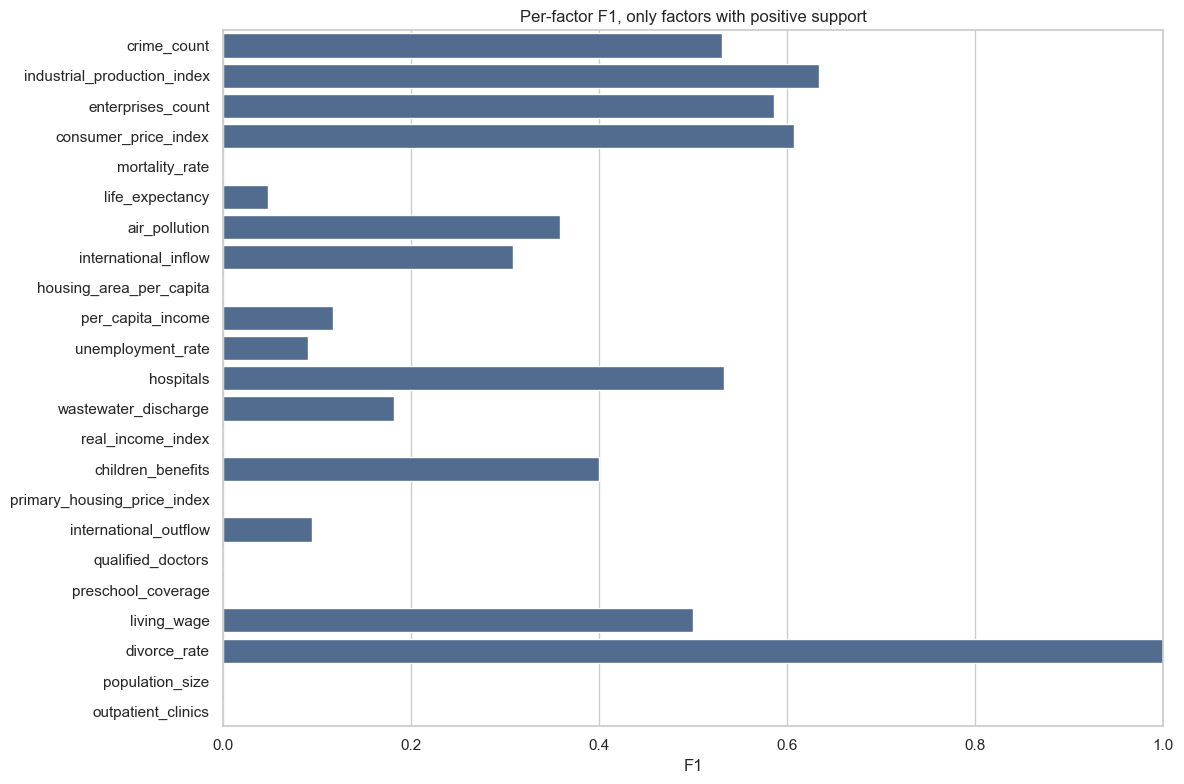

In [11]:
if final_row["mode"] == "default":
    final_pred_matrix = best_prompt_cache["default_labels"]
else:
    final_pred_matrix = (best_prompt_cache["scores"] >= float(final_row["threshold"])).astype(int)

precision, recall, f1, support = precision_recall_fscore_support(
    y_true,
    final_pred_matrix,
    average=None,
    zero_division=0,
)
factor_report = pd.DataFrame(
    {
        "factor_key": factor_keys,
        "factor_name": [factor_names[key] for key in factor_keys],
        "support": support.astype(int),
        "predicted_positive": final_pred_matrix.sum(axis=0).astype(int),
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }
).sort_values(["support", "f1"], ascending=[False, False])

display(factor_report.round(4))

fig, ax = plt.subplots(figsize=(12, 8))
plot_df = factor_report[factor_report["support"] > 0].copy()
sns.barplot(data=plot_df, y="factor_key", x="f1", color="#486a9a", ax=ax)
ax.set_title("Per-factor F1, only factors with positive support")
ax.set_xlabel("F1")
ax.set_ylabel("")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

## 11. Sentiment metrics на релевантных парах

In [12]:
def sentiment_pair_table(y: np.ndarray, p: np.ndarray, true_sentiment: pd.DataFrame, pred_sentiment_matrix: np.ndarray) -> pd.DataFrame:
    rows = []
    for row_idx, dataset_row_id in enumerate(true_sentiment.index):
        for factor_idx, factor_key in enumerate(factor_keys):
            if y[row_idx, factor_idx] != 1:
                continue
            true_label = normalize_sentiment_label(true_sentiment.iloc[row_idx][factor_key])
            predicted_pair = bool(p[row_idx, factor_idx] == 1)
            pred_label = normalize_sentiment_label(pred_sentiment_matrix[row_idx, factor_idx]) if predicted_pair else "__missed_factor__"
            rows.append(
                {
                    "dataset_row_id": int(dataset_row_id),
                    "factor_key": factor_key,
                    "true_sentiment": true_label,
                    "predicted_pair": predicted_pair,
                    "pred_sentiment": pred_label,
                    "sentiment_correct": predicted_pair and true_label == pred_label,
                }
            )
    return pd.DataFrame(rows)

sentiment_pairs = sentiment_pair_table(
    y_true,
    final_pred_matrix,
    sentiment_true,
    best_prompt_cache["sentiment_matrix"],
)
display(sentiment_pairs["true_sentiment"].value_counts().rename("true_pairs").to_frame())
display(pd.crosstab(sentiment_pairs["true_sentiment"], sentiment_pairs["pred_sentiment"], dropna=False))

sentiment_by_factor = (
    sentiment_pairs.groupby("factor_key")
    .agg(
        true_pairs=("factor_key", "size"),
        predicted_true_pairs=("predicted_pair", "sum"),
        sentiment_accuracy_all_true_pairs=("sentiment_correct", "mean"),
    )
    .reset_index()
    .merge(factor_report[["factor_key", "support", "f1"]], on="factor_key", how="left")
    .sort_values("true_pairs", ascending=False)
)
display(sentiment_by_factor.round(4))

,true_pairs
true_sentiment,
negative,526
positive,374
neutral,15


pred_sentiment,__missed_factor__,negative,neutral,positive
true_sentiment,,,,
negative,318,141,64,3
neutral,6,2,7,0
positive,176,29,81,88


,factor_key,true_pairs,predicted_true_pairs,sentiment_accuracy_all_true_pairs,support,f1
3,crime_count,244,98,0.2623,244,0.5312
8,industrial_production_index,206,144,0.3786,206,0.6344
5,enterprises_count,157,75,0.2548,157,0.5859
2,consumer_price_index,66,51,0.4545,66,0.6071
13,mortality_rate,44,0,0.0000,44,0.0000
11,life_expectancy,41,1,0.0000,41,0.0476
0,air_pollution,37,12,0.1081,37,0.3582
9,international_inflow,28,23,0.3571,28,0.3087
7,housing_area_per_capita,20,0,0.0000,20,0.0000
15,per_capita_income,16,1,0.0625,16,0.1176


## 12. Ошибки на уровне новости

In [13]:
def factors_from_vector(vector: np.ndarray) -> list[str]:
    return [factor_keys[idx] for idx in np.where(vector == 1)[0]]

error_rows = []
for row_idx, dataset_row_id in enumerate(ids_full):
    true_set = set(factors_from_vector(y_true[row_idx]))
    pred_set = set(factors_from_vector(final_pred_matrix[row_idx]))
    tp = sorted(true_set & pred_set)
    fp = sorted(pred_set - true_set)
    fn = sorted(true_set - pred_set)
    union = true_set | pred_set
    sample_jaccard = 1.0 if not union else len(true_set & pred_set) / len(union)
    sample_f1 = 1.0 if not (true_set or pred_set) else 2 * len(tp) / max(1, len(true_set) + len(pred_set))
    error_rows.append(
        {
            "dataset_row_id": int(dataset_row_id),
            "title": df.iloc[row_idx][title_col] if title_col in df.columns else "",
            "url": df.iloc[row_idx][url_col] if url_col in df.columns else "",
            "true_factors": ";".join(sorted(true_set)),
            "pred_factors": ";".join(sorted(pred_set)),
            "tp_factors": ";".join(tp),
            "fp_factors": ";".join(fp),
            "fn_factors": ";".join(fn),
            "true_count": len(true_set),
            "pred_count": len(pred_set),
            "sample_f1": sample_f1,
            "sample_jaccard": sample_jaccard,
            "needs_review": bool(fp or fn),
        }
    )

news_errors = pd.DataFrame(error_rows).sort_values(["sample_f1", "true_count"], ascending=[True, False])
display(news_errors.head(40))

,dataset_row_id,title,url,true_factors,pred_factors,tp_factors,fp_factors,fn_factors,true_count,pred_count,sample_f1,sample_jaccard,needs_review
20,21,В Херсонской области в результате обстрела ранены водитель и врач скорой помощи,https://www.interfax.ru/russia/1047733,crime_count;hospitals;qualified_doctors,,,,crime_count;hospitals;qualified_doctors,3,0,0.0,0.0,True
6,7,Женщина погибла в результате атаки беспилотников ВСУ на населенный пункт Вахрушево в ЛНР,https://www.interfax.ru/russia/1033570,crime_count;mortality_rate,,,,crime_count;mortality_rate,2,0,0.0,0.0,True
15,16,Состояние пострадавших при ЧП в Курской области сотрудников РЖД удовлетворительное,https://www.interfax.ru/russia/1028966,life_expectancy;mortality_rate,hospitals,,hospitals,life_expectancy;mortality_rate,2,1,0.0,0.0,True
38,39,"В Турции заявили, что танкер Virat подвергся повторной атаке в Черном море",https://www.interfax.ru/world/1060587,air_pollution;crime_count,international_outflow,,international_outflow,air_pollution;crime_count,2,1,0.0,0.0,True
52,53,"Что произошло за день: понедельник, 1 декабря",https://www.interfax.ru/russia/1060876,international_inflow;life_expectancy,crime_count,,crime_count,international_inflow;life_expectancy,2,1,0.0,0.0,True
120,121,Проект о передаче под контроль ЦБ регулирования сервисов покупок в рассрочку принят в I чтении,https://www.interfax.ru/russia/1016396,per_capita_income;real_income_index,consumer_price_index,,consumer_price_index,per_capita_income;real_income_index,2,1,0.0,0.0,True
128,129,"Что произошло за день: вторник, 13 мая",https://www.interfax.ru/world/1025425,air_pollution;crime_count,international_inflow,,international_inflow,air_pollution;crime_count,2,1,0.0,0.0,True
139,140,"Что произошло за день: четверг, 3 апреля",https://www.interfax.ru/russia/1018179,consumer_price_index;mortality_rate,crime_count;industrial_production_index,,crime_count;industrial_production_index,consumer_price_index;mortality_rate,2,2,0.0,0.0,True
144,145,Госдума утвердила отчет об исполнении бюджетов ФОМС и Социального фонда за 2024 год,https://www.interfax.ru/russia/1035392,children_benefits;hospitals,,,,children_benefits;hospitals,2,0,0.0,0.0,True
158,159,"""АвтоВАЗ"" возобновил производство после корпоративного отпуска и майских праздников",https://www.interfax.ru/business/1025077,industrial_production_index;unemployment_rate,enterprises_count,,enterprises_count,industrial_production_index;unemployment_rate,2,1,0.0,0.0,True


## 13. Сохранение итоговых артефактов

In [14]:
output_paths = {
    "summary": OUTPUT_DIR / "final_multilabel_llm_evaluation_summary.json",
    "prompt_search_metrics": OUTPUT_DIR / "final_multilabel_prompt_search_metrics.csv",
    "full_metrics": OUTPUT_DIR / "final_multilabel_full_metrics.csv",
    "threshold_sweep": OUTPUT_DIR / "final_multilabel_threshold_sweep.csv",
    "factor_report": OUTPUT_DIR / "final_multilabel_per_factor_report.csv",
    "sentiment_pairs": OUTPUT_DIR / "final_multilabel_sentiment_pairs.csv",
    "sentiment_by_factor": OUTPUT_DIR / "final_multilabel_sentiment_by_factor.csv",
    "news_errors": OUTPUT_DIR / "final_multilabel_news_errors.csv",
}

search_metrics.to_csv(output_paths["prompt_search_metrics"], index=False, encoding="utf-8-sig")
full_metrics.to_csv(output_paths["full_metrics"], index=False, encoding="utf-8-sig")
threshold_sweep.to_csv(output_paths["threshold_sweep"], index=False, encoding="utf-8-sig")
factor_report.to_csv(output_paths["factor_report"], index=False, encoding="utf-8-sig")
sentiment_pairs.to_csv(output_paths["sentiment_pairs"], index=False, encoding="utf-8-sig")
sentiment_by_factor.to_csv(output_paths["sentiment_by_factor"], index=False, encoding="utf-8-sig")
news_errors.to_csv(output_paths["news_errors"], index=False, encoding="utf-8-sig")

summary = {
    "dataset_path": str(DATASET_PATH),
    "dataset_stats": dataset_stats,
    "catalog_audit": catalog_audit,
    "encoding_audit": encoding_audit,
    "available_prediction_files": prediction_index.to_dict(orient="records"),
    "metric_policy": {
        "primary": "factor_micro_f1 over 36 binary factor labels",
        "secondary": [
            "factor_macro_f1_supported",
            "per-factor F1",
            "sample_f1_empty_correct",
            "sentiment accuracy/F1 on relevant news-factor pairs",
            "any_relevant_f1 for relevance gate",
        ],
        "not_headline": "single-label macro-F1 over not_relevant + 36 factors",
    },
    "best_prompt": str(best_variant),
    "best_full_run": str(final_row["name"]),
    "best_full_metrics": {
        key: float(value)
        for key, value in final_row.items()
        if isinstance(value, (int, float, np.integer, np.floating)) and not pd.isna(value)
    },
    "production_default_metrics": {
        key: float(value)
        for key, value in production_default.items()
        if isinstance(value, (int, float, np.integer, np.floating)) and not pd.isna(value)
    },
    "balanced_default_metrics": {
        key: float(value)
        for key, value in balanced_default.items()
        if isinstance(value, (int, float, np.integer, np.floating)) and not pd.isna(value)
    },
    "zero_support_factor_keys": zero_support_factor_keys,
    "output_paths": {key: str(value) for key, value in output_paths.items()},
}
output_paths["summary"].write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")

display(
    Markdown(
        f'''
        ## Финальный вывод

        Лучший prompt по новой multilabel-оценке: `{best_variant}`.

        Лучший full run: `{final_row['name']}`.

        `factor_micro_f1`: **{final_row['factor_micro_f1']:.3f}**.

        `factor_macro_f1_supported`: **{final_row['factor_macro_f1_supported']:.3f}**.

        `sample_f1_empty_correct`: **{final_row['sample_f1_empty_correct']:.3f}**.

        `any_relevant_f1`: **{final_row['any_relevant_f1']:.3f}**.

        `sentiment_accuracy_on_predicted_true_pairs`: **{final_row['sentiment_accuracy_on_predicted_true_pairs']:.3f}**.

        `sentiment_accuracy_all_true_pairs_missed_wrong`: **{final_row['sentiment_accuracy_all_true_pairs_missed_wrong']:.3f}**.

        Реальная картина: gate релевантности уже заметно сильнее, чем извлечение точного набора факторов.
        Основная зона роста — recall и различение близких факторов, а не UTF-8 и не старый single-label F1.
        '''
    )
)

print("Saved artifacts:")
for key, value in output_paths.items():
    print(f"- {key}: {value}")


        ## Финальный вывод

        Лучший prompt по новой multilabel-оценке: `balanced_recall_v2`.

        Лучший full run: `balanced_recall_v2__threshold_0.15`.

        `factor_micro_f1`: **0.489**.

        `factor_macro_f1_supported`: **0.261**.

        `sample_f1_empty_correct`: **0.488**.

        `any_relevant_f1`: **0.809**.

        `sentiment_accuracy_on_predicted_true_pairs`: **0.569**.

        `sentiment_accuracy_all_true_pairs_missed_wrong`: **0.258**.

        Реальная картина: gate релевантности уже заметно сильнее, чем извлечение точного набора факторов.
        Основная зона роста — recall и различение близких факторов, а не UTF-8 и не старый single-label F1.
        

Saved artifacts:
- summary: C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\final_multilabel_llm_evaluation_summary.json
- prompt_search_metrics: C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\final_multilabel_prompt_search_metrics.csv
- full_metrics: C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\final_multilabel_full_metrics.csv
- threshold_sweep: C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\final_multilabel_threshold_sweep.csv
- factor_report: C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\final_multilabel_per_factor_report.csv
- sentiment_pairs: C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\final_multilabel_sentiment_pairs.csv
- sentiment_by_factor: C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\final_multilabel_sentiment_by_factor.csv
- news_errors: C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\final_multilabel_news_errors.csv
